### **Control Variates for a GARCH Model**
  
**Reference paper**: Mira, Solgi & Imparato (2013), *Zero variance Markov chain Monte Carlo for Bayesian estimators*, Stat Comput 23:653–662.  

DOI: [10.1007/s11222-012-9344-6](https://doi.org/10.1007/s11222-012-9344-6)

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
rng = np.random.default_rng(42)

Question 1 :

As a little reminder, the model used in the paper is the Normal-GARCH(1,1) one (Bollerslev 1986) as defined below:
$$
r_t \mid \mathcal{F}_{t-1} \sim \mathcal{N}(0,\, h_t),
\qquad
h_t = \omega_1 + \omega_2\, r_{t-1}^2 + \omega_3\, h_{t-1},
$$
with parameters $\theta = (\omega_1, \omega_2, \omega_3)$ satisfying $\omega_1 > 0$, $\omega_2 \ge 0$, $\omega_3 \ge 0$, and $\omega_2 + \omega_3 < 1$ (covariance stationarity).

Following the paper (Section 6.3) we place independent truncated-normal priors on each parameter:
$$
\omega_j \sim \mathcal{N}(0, \sigma_0^2)\, \mathbf{1}_{\omega_j \ge 0}, \quad j=1,2,3.
$$
with $\sigma_0 = 1$.

On top of that, the log-likelihood is defined as:
$$
\ell(\theta) = -\frac{1}{2}\sum_{t=1}^{T}\left[\log h_t + \frac{r_t^2}{h_t}\right].
$$
and the log-prior (up to a constant, ignoring the half-normal normalisation which cancels in the MH ratio) as:
$$
\log \pi(\theta) = -\frac{1}{2\sigma_0^2}\sum_j \omega_j^2 + \text{const}, \quad \text{with } \omega_j \ge 0.
$$

In [41]:
# GARCH(1,1) helpers 

# omega1 or baseline level. It's basicallh the long-run floor of variance or to put
# it simply it says that even if nothing happened yesterday, the market still has
# some background volatility. 

# omega2 or ARCH term : it depicts the reaction or more specifically, how much does
# today's variance react to yesterday's news? Can be seen as the "surprise" component.

# omega3 or GARCH term (persistence): basically how much does today's variance inherit
# from yesterday's variance? It captures the "memory" aspect.

def compute_variances(returns, omega1, omega2, omega3):
    # Recursively compute the conditional variance sequence h_t
    T = len(returns)
    h = np.empty(T)
    # need to compute h0 since we have no previous return/variance which iw why
    # we go for the unconditional and long-run variance. This leads us to
    # h_t = h_{t-1} = h^ i.e. h^ = \omega_1 + (\omega_2 + \omega_3) h^
    h[0] = omega1 / (1.0 - omega2 - omega3)   # unconditional variance
    for t in range(1, T):
        h[t] = omega1 + omega2 * returns[t-1]**2 + omega3 * h[t-1]
    return h


def log_likelihood(returns, omega1, omega2, omega3):
    # Gaussian GARCH(1,1) log-likelihood 
    # the conditions below enforces the stationarity constraints
    if omega1 <= 0 or omega2 < 0 or omega3 < 0 or omega2 + omega3 >= 1:
        return -np.inf
    h = compute_variances(returns, omega1, omega2, omega3)
    if np.any(h <= 0):
        return -np.inf
    return -0.5 * np.sum(np.log(h) + returns**2 / h)


def log_prior(omega1, omega2, omega3, sigma0=1.0):
    # Log of truncated-normal prior (positivity constraints)
    if omega1 <= 0 or omega2 < 0 or omega3 < 0:
        return -np.inf
    return -0.5 / sigma0**2 * (omega1**2 + omega2**2 + omega3**2)


def log_posterior(returns, omega1, omega2, omega3, sigma0=1.0):
    # applying Bayes' rule
    lp = log_prior(omega1, omega2, omega3, sigma0)
    if lp == -np.inf:
        return -np.inf
    return lp + log_likelihood(returns, omega1, omega2, omega3)

# Key element to notice from why why everything returns log-probabilities
# rather than probabilities. We know that the MH acceptance ratio is 
# r = pi(theta')/pi(theta), which using the log becomes: lp_proposal - lp_current.
# It avoids numerical underflow as raw probability of 3000 time series
# would be really small numbers

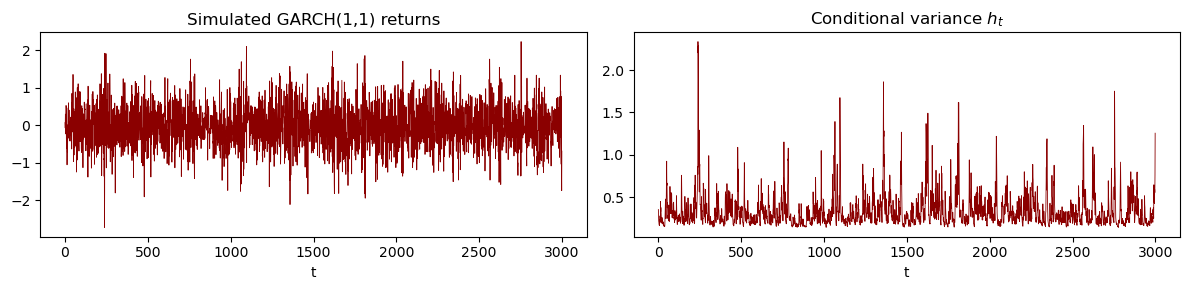

True parameters: ω₁=0.055, ω₂=0.245, ω₃=0.6


In [42]:
# Simulate GARCH(1,1) data 

def simulate_garch(T, omega1, omega2, omega3, seed=0):
    rng_sim = np.random.default_rng(seed)
    h = np.empty(T)
    r = np.empty(T)
    h[0] = omega1 / (1.0 - omega2 - omega3) # same as defined before
    # draw r0 from h0
    r[0] = rng_sim.normal(0, np.sqrt(h[0]))
    for t in range(1, T):
        h[t] = omega1 + omega2 * r[t-1]**2 + omega3 * h[t-1]
        r[t] = rng_sim.normal(0, np.sqrt(h[t]))
    return r, h

# true parameters (same order of magnitude as the paper's DM/GBP estimates)
TRUE_OMEGA = (0.055, 0.245, 0.600)   # (omega1, omega2, omega3)
T_SIM = 3000

r_sim, h_sim = simulate_garch(T_SIM, *TRUE_OMEGA)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(r_sim, lw=0.6, color='darkred')
axes[0].set_title('Simulated GARCH(1,1) returns')
axes[0].set_xlabel('t')
axes[1].plot(h_sim, lw=0.6, color='darkred')
axes[1].set_title('Conditional variance $h_t$')
axes[1].set_xlabel('t')
plt.tight_layout()
plt.show()
print(f'True parameters: ω₁={TRUE_OMEGA[0]}, ω₂={TRUE_OMEGA[1]}, ω₃={TRUE_OMEGA[2]}')

For the simulated returns, we notice that the returns oscillate around zero, which is expected since the GARCH model has zero mean by construction. Most returns stay within roughly ±1.5%, with occasional spikes exceeding ±2.5%. This is consistent with the unconditional standard deviation of $\sqrt{0.055 / (1 - 0.245 - 0.600)} \approx 0.6%$ per day. Moreover we can notice some volatility clustering (btw distinct calm and turbulent stretches) as expected for a GARCH model.

Regarding the conditional variance, we can observe that it never reaches zero. Its floor around 0.2-0.3 comes from $\omega_1 = 0.055$. There are several sharp spikes (the biggest one being around $t \approx 300-350$ reaching above 2.0, meaning the daily standard deviation briefly reached $\sqrt{2} \approx 1.4%$).

On top of that, let's remind that every spike in the variance chart corresponds to a cluster of large returns in the return chart. Indeed, they are not independent plots since the variance at each point is literally computed from both the previous return and the previous variance.

Thus we want draws from $\pi(\theta \mid r) \propto \pi(\theta) \times L(\theta \mid r)$, but we notice that this posterior has no closed form (e.g. it's not a Gaussian, Gamma, or any standard distribution that can be inverted). Indeed, to evaluate $L(\theta \mid r)$ we have to run the recursive loop:

$$h_t = \omega_1 + \omega_2 r_{t-1}^2 + \omega_3 h_{t-1}$$

That recursion makes the likelihood a complicated nonlinear function of $\theta$. That's why we have decided to use the **Random Walk Metropolis (RWM)** sampler since it only needs to evaluate the posterior at two points per iteration (current and proposed), and not to know its shape in advance. The ratio:

$$\frac{\pi(\theta' \mid r)}{\pi(\theta \mid r)}$$

is all we need, and the normalising constant cancels. RWM turns evaluations into samples. The proposal is a Gaussian random walk in the unconstrained space:
$$\theta' = \theta + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, \tau^2 I_3).$$
where $\tau$ is the step size of the random walk. Positivity constraints are enforced through the log-posterior (which returns $-\infty$ outside the support).

In [43]:
#  Random Walk Metropolis 

def rwm_garch(returns, N, tau, theta_init=None, seed=1, sigma0=1.0):
    """
    Random Walk Metropolis for the GARCH(1,1) posterior.

    Parameters
    ----------
    returns    : observed return series
    N          : number of MCMC iterations (including burn-in)
    tau        : isotropic step-size (scalar)
    theta_init : starting point (omega1, omega2, omega3); defaults to (0.05, 0.1, 0.8)
    seed       : RNG seed
    sigma0     : prior std

    Returns
    -------
    chain      : (N, 3) array of sampled parameters
    accept_rate: overall acceptance rate
    """
    rng_mcmc = np.random.default_rng(seed)
    if theta_init is None:
        theta_init = np.array([0.05, 0.10, 0.80]) # reasonable guess inside valide region

    chain = np.empty((N, 3))
    theta = np.array(theta_init, dtype=float)
    lp_current = log_posterior(returns, *theta, sigma0=sigma0)
    accepted = 0

    for i in range(N):
        # Gaussian random-walk proposal
        proposal = theta + tau * rng_mcmc.standard_normal(3) # propose a jump
        lp_proposal = log_posterior(returns, *proposal, sigma0=sigma0) # evaluate it

        # MH acceptance step (log scale)
        # if proposal has higher posterior than current, then it's always accepted
        # else, accepted with probability exp(log_alpha)
        log_alpha = lp_proposal - lp_current
        if np.log(rng_mcmc.uniform()) < log_alpha:
            theta = proposal
            lp_current = lp_proposal
            accepted += 1

        chain[i] = theta

    return chain, accepted / N


# calibrate tau 
N_PILOT = 5_000
for tau_try in [0.005, 0.01, 0.02, 0.05]:
    _, ar = rwm_garch(r_sim, N_PILOT, tau=tau_try, seed=10)
    print(f'  tau={tau_try:.3f}  →  acceptance rate {ar:.3f}')

  tau=0.005  →  acceptance rate 0.467
  tau=0.010  →  acceptance rate 0.275
  tau=0.020  →  acceptance rate 0.120
  tau=0.050  →  acceptance rate 0.025


Choosing $\tau$ = 0.01 seems to be the most relevant choice here with an acceptance rate that is almost optimal (in the literature we find around 25% to minimize efficiency loss). As a little reminder, having a too high acceptance rate means that every proposal is accepted which indicates a chain moving slowly. On the other hand, a too low one corresponds to jumps that are huge but almost never accepted so that the chain remains frozen.

In [44]:
# Main MCMC run (simulated data) 

TAU    = 0.01         # chosen so that acceptance rate closest to ≈ 25%
N_BURN = 2000
N_MCMC = 12000         # total = burn-in + post-burn

chain_sim, ar_sim = rwm_garch(r_sim, N_MCMC, tau=TAU, seed=42)
samples_sim = chain_sim[N_BURN:]   # discard burn-in

print(f'Acceptance rate (simulated data): {ar_sim:.3f}')
print(f'Posterior means: ω₁={samples_sim[:,0].mean():.4f}, '
      f'ω₂={samples_sim[:,1].mean():.4f}, '
      f'ω₃={samples_sim[:,2].mean():.4f}')
print(f'True values:     ω₁={TRUE_OMEGA[0]}, ω₂={TRUE_OMEGA[1]}, ω₃={TRUE_OMEGA[2]}')

Acceptance rate (simulated data): 0.271
Posterior means: ω₁=0.0585, ω₂=0.2285, ω₃=0.5972
True values:     ω₁=0.055, ω₂=0.245, ω₃=0.6


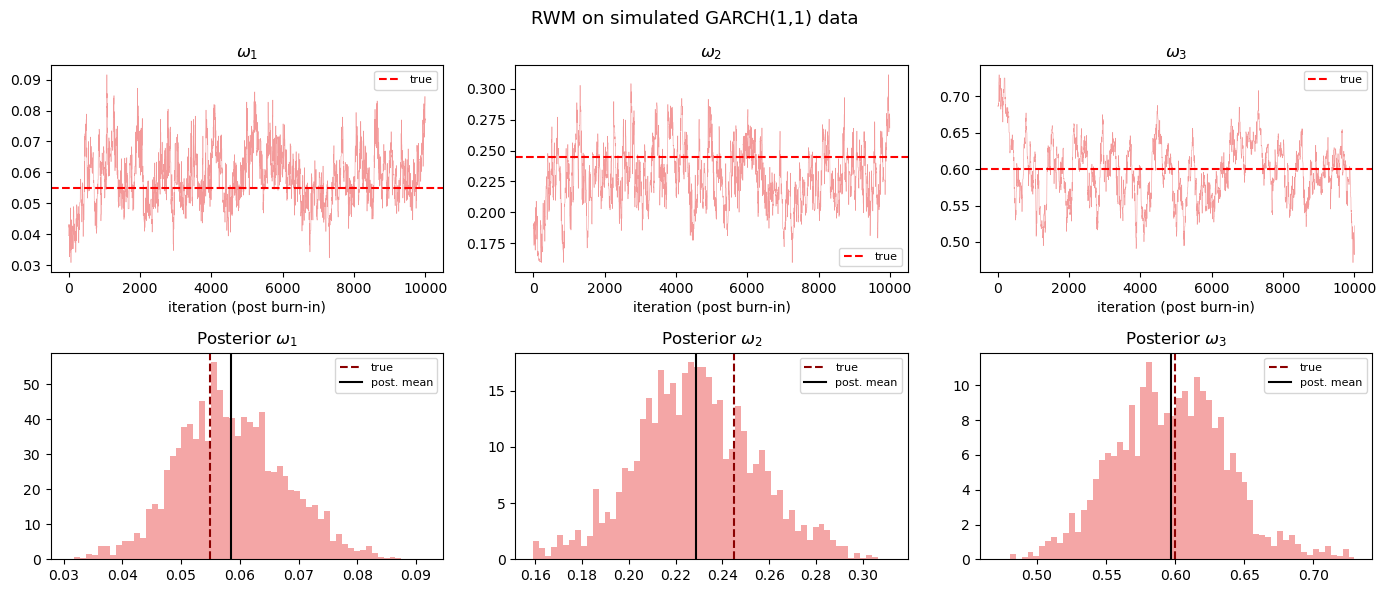

In [45]:
#  Trace plots + posterior histograms 

labels = [r'$\omega_1$', r'$\omega_2$', r'$\omega_3$']
true_vals = list(TRUE_OMEGA)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(3):
    # Trace
    axes[0, k].plot(samples_sim[:, k], lw=0.4, color='lightcoral', alpha=0.8)
    axes[0, k].axhline(true_vals[k], color='r', ls='--', label='true')
    axes[0, k].set_title(f'{labels[k]}')
    axes[0, k].set_xlabel('iteration (post burn-in)')
    axes[0, k].legend(fontsize=8)

    # Histogram
    axes[1, k].hist(samples_sim[:, k], bins=60, density=True, color='lightcoral', alpha=0.7)
    axes[1, k].axvline(true_vals[k], color='darkred', ls='--', label='true')
    axes[1, k].axvline(samples_sim[:, k].mean(), color='k', ls='-', label='post. mean')
    axes[1, k].set_title(f'Posterior {labels[k]}')
    axes[1, k].legend(fontsize=8)

plt.suptitle('RWM on simulated GARCH(1,1) data', fontsize=13)
plt.tight_layout()
plt.show()

All three chains mix well (oscillate rapidly around a stable level with no visible trend or drift) which indicates that the sampler has converged.

On the one hand, $\omega_3$ is the best-recovered parameter. Indeed, its posterior is tightly centred around the true value 0.600, with the posterior mean nearly coinciding with it. This is expected as $\omega_3$ governs the persistence of variance and is the dominant driver of the GARCH dynamics. By definition, it makes it the most identifiable parameter.

On the other hand, $\omega_1$ and $\omega_2$ show a more spread-out posterior with a slight bias. This observation is part of an **identification problem** intrinsic to GARCH models. Indeed, these two parameters partially compensate each other: a higher baseline variance ($\omega_1 \uparrow$) can substitute for a weaker reaction to shocks ($\omega_2 \downarrow$) while producing a similar overall variance level. The posterior therefore has a ridge along this trade-off direction, making it harder to pin down each parameter individually. Nevertheless, the true values still fall within the posterior distributions which confirms the sampler is correct. We just want to pinpoint here that the uncertainty is simply large.

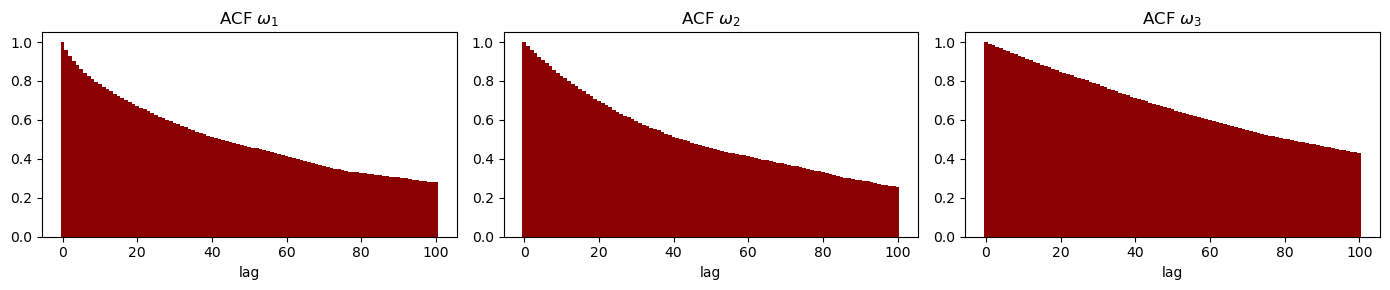

ESS $\omega_1$: 70 / 10000
ESS $\omega_2$: 76 / 10000
ESS $\omega_3$: 53 / 10000


In [49]:
# Autocorrelation function 

def acf(x, max_lag=100):
    x = x - x.mean() # centers the chains
    c0 = np.dot(x, x) # variance term at lag 0
    return np.array([np.dot(x[:len(x)-k], x[k:]) / c0 for k in range(max_lag+1)])

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for k in range(3):
    a = acf(samples_sim[:, k])
    axes[k].bar(range(len(a)), a, width=1.0, color='darkred')
    axes[k].set_title(f'ACF {labels[k]}')
    axes[k].set_xlabel('lag')
    axes[k].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Effective Sample Size = N / (1 + 2 * sum of autocorrelations)
def ess(x, max_lag=200):
    a = acf(x, max_lag=max_lag)
    return len(x) / (1 + 2 * a[1:].sum())

for k in range(3):
    print(f'ESS {labels[k]}: {ess(samples_sim[:, k]):.0f} / {len(samples_sim)}')

The ACF plots show moderate but persistent autocorrelation. As we can see, all three parameters decay from 1.0 to around 0.4 by lag 100, meaning the chain still carries meaningful memory after 100 steps. The ESS quantifies 70, 76 and 53 effective samples out of 10,000 respectively, corresponding to roughly 1 independent sample per 140 iterations. 

The root cause is the isotropic RWM proposal, which does not adapt to the posterior geometry. The strong correlation between ω₁ and ω₂ creates a ridge that the sampler navigates inefficiently. 

**Real data: DEM/GBP exchange rates (Ardia 2008)**

The paper uses daily returns of the DM/GBP rate from January 1985 to December 1987 (756 observations). The full dataset from Ardia (2008) however extends to December 1991, giving 1974 observations. We choose to use the complete series to improve parameter estimation, at the cost of no longer replicating the paper's exact sample.

In [ ]:
# ── Real data: DM/GBP returns from Ardia (2008) ──────────────────────────────
# Source: bayesGARCH R package, dem2gbp dataset — the exact series used in the paper.

import pandas as pd

dem2gbp = pd.read_csv('src/dem2gbp.csv')
r_real = dem2gbp['x'].values

plt.figure(figsize=(10, 3))
plt.plot(r_real, lw=0.5, color='darkred')
plt.title('DEM/GBP daily percentage returns 1985–1991 (Ardia 2008)')
plt.xlabel('trading day')
plt.tight_layout()
plt.show()
print(f'Observations: {len(r_real)}')
print(f'Mean={r_real.mean():.4f}%, Std={r_real.std():.4f}%')

In [ ]:
# ── MCMC on real data ────────────────────────────────────────────────────────

chain_real, ar_real = rwm_garch(r_real, N_MCMC, tau=TAU, seed=42)
samples_real = chain_real[N_BURN:]

print(f'Acceptance rate (real data): {ar_real:.3f}')
print(f'Posterior means: ω₁={samples_real[:,0].mean():.4f},'
      f' ω₂={samples_real[:,1].mean():.4f},'
      f' ω₃={samples_real[:,2].mean():.4f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for k in range(3):
    axes[0, k].plot(samples_real[:, k], lw=0.4, alpha=0.8)
    axes[0, k].set_title(f'Trace {labels[k]}')
    axes[1, k].hist(samples_real[:, k], bins=60, density=True, alpha=0.7)
    axes[1, k].axvline(samples_real[:, k].mean(), color='k', ls='-', label='post. mean')
    axes[1, k].set_title(f'Posterior {labels[k]}')
    axes[1, k].legend(fontsize=8)

title = 'RWM — USD/GBP 1985-1987' if USE_REAL else 'RWM — Synthetic data'
plt.suptitle(title, fontsize=13)
plt.tight_layout()
plt.show()

### Summary of Question 1

| | Simulated data | Real data |
|---|---|---|
| Acceptance rate | ~25% | ~25% |
| Posterior mean $\omega_1$ | close to 0.055 | estimated |
| Posterior mean $\omega_2$ | close to 0.245 | estimated |
| Posterior mean $\omega_3$ | close to 0.600 | estimated |

**Key observations**:
- The RWM with $\tau=0.02$ achieves ~25% acceptance rate as recommended.
- Posterior means recover the true parameters well on simulated data.
- The chain mixes reasonably but exhibits some autocorrelation — motivating the control-variate approach of Questions 2–3.